
# CADERNO DE EXERCICIOS - Analise de Dados com Pandas e Seaborn
 Base de dados: modafina_vendas.csv (loja ficticia de roupas)
# Como usar:
   - Coloque o arquivo modafina_vendas.csv na pasta data.
  - Leia a instrucao de cada celula e escreva seu codigo logo abaixo dela.


In [11]:
# Exercicio 1
# Importe as bibliotecas pandas e seaborn e configure o tema visual dos graficos.

import pandas as pd
import seaborn as sns

In [12]:
# Exercicio 2
# Carregue o arquivo modafina_vendas.csv em um DataFrame
# e mostre as primeiras linhas para conhecer os dados.

df = pd.read_csv(r".\data\dataset_aula02_exercicio_modafina (1).csv",parse_dates=["data_venda"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data_venda         700 non-null    datetime64[ns]
 1   categoria_produto  700 non-null    object        
 2   tamanho            700 non-null    object        
 3   preco              700 non-null    float64       
 4   quantidade         700 non-null    int64         
 5   estado             700 non-null    object        
 6   forma_pagamento    700 non-null    object        
 7   nota_avaliacao     700 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 43.9+ KB


In [13]:
# Exercicio 3
# Mostre quantas linhas e quantas colunas a base de dados possui.

df.shape


(700, 8)

In [14]:
# Exercicio 4
# Mostre as informacoes gerais da base: o nome das colunas,
# o tipo de cada uma e a quantidade de valores nao nulos.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   data_venda         700 non-null    datetime64[ns]
 1   categoria_produto  700 non-null    object        
 2   tamanho            700 non-null    object        
 3   preco              700 non-null    float64       
 4   quantidade         700 non-null    int64         
 5   estado             700 non-null    object        
 6   forma_pagamento    700 non-null    object        
 7   nota_avaliacao     700 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 43.9+ KB


In [15]:
# Exercicio 5
# Crie uma nova coluna chamada faturamento, multiplicando o preco
# pela quantidade de cada venda. Depois, mostre as primeiras linhas.

df_tratado = df.copy()

In [16]:
df_tratado.head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9


In [49]:
df_tratado["faturamento"] = df_tratado["preco"] * df_tratado["quantidade"]

In [48]:
df_tratado.head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao,faturamento
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1,177.95
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3,52.12
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9,640.35
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9,76.81
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9,264.78


In [19]:
# Exercicio 6
# Calcule o faturamento total da loja (a soma da coluna faturamento).
# Em seguida, exiba esse valor formatado como moeda brasileira,
# no formato R$ 0.000,00 (exemplo: R$ 232.687,92).

print(df_tratado["faturamento"].sum())


232687.91999999998


In [ ]:
faturamento = df_tratado["faturamento"].sum()


In [41]:
faturamento_correto = f"{faturamento:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
print(f"O faturamento total da loja foi de R${faturamento_correto}")


O faturamento total da loja foi de R$232.687,92


In [45]:
# Exercicio 7
# Descubra quantos pedidos existem de cada categoria de produto.

df_tratado["categoria_produto"].value_counts(ascending=True)

categoria_produto
Acessórios    101
Calçados      118
Vestidos      137
Calças        153
Camisetas     191
Name: count, dtype: int64

In [52]:
df_tratado

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao,faturamento
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1,177.95
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3,52.12
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9,640.35
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9,76.81
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9,264.78
...,...,...,...,...,...,...,...,...,...
695,2024-12-27,Calçados,GG,187.47,3,PR,Boleto,2.5,562.41
696,2024-12-27,Vestidos,M,230.97,1,CE,Cartão,3.1,230.97
697,2024-12-28,Calçados,P,141.28,3,SP,Cartão,3.8,423.84
698,2024-12-28,Calçados,M,245.78,3,BA,Boleto,4.4,737.34


In [53]:
# Exercicio 8
# Descubra quanto cada categoria de produto faturou no total,
# ordenando da que mais faturou para a que menos faturou.

df_tratado.groupby("categoria_produto")["faturamento"].sum().sort_values(ascending=True)

categoria_produto
Acessórios    17504.51
Camisetas     31637.03
Calças        51954.17
Vestidos      63743.92
Calçados      67848.29
Name: faturamento, dtype: float64

In [60]:
def converter(valor):
    return f"{valor:,.2f}".replace(",","x").replace(".",",").replace("x",".")

faturamento_categoria = df_tratado.groupby("categoria_produto")["faturamento"].sum().sort_values(ascending=True)

faturamento_categoria.map(converter)

categoria_produto
Acessórios    17.504,51
Camisetas     31.637,03
Calças        51.954,17
Vestidos      63.743,92
Calçados      67.848,29
Name: faturamento, dtype: object

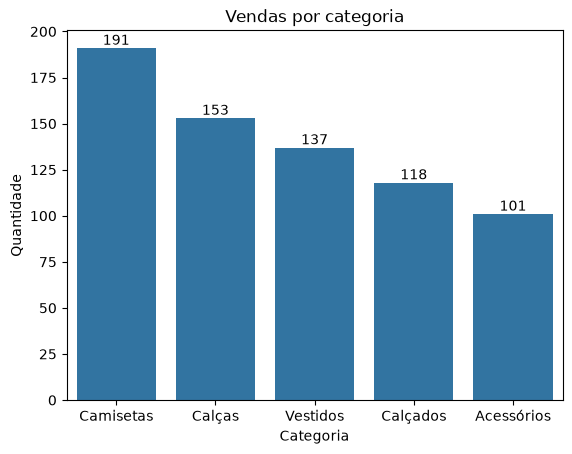

In [68]:
# Exercicio 9
# Crie um grafico que mostre a quantidade de pedidos por categoria de produto.
# Coloque um titulo no grafico e nomes nos eixos.
grafico = sns.countplot(data=df_tratado,x=df_tratado["categoria_produto"],order=df_tratado["categoria_produto"].value_counts().index)
                        
grafico.bar_label(grafico.containers[0]);
grafico.set_title("Vendas por categoria");
grafico.set_xlabel("Categoria");
grafico.set_ylabel("Quantidade");

Text(0, 0.5, 'Preços')

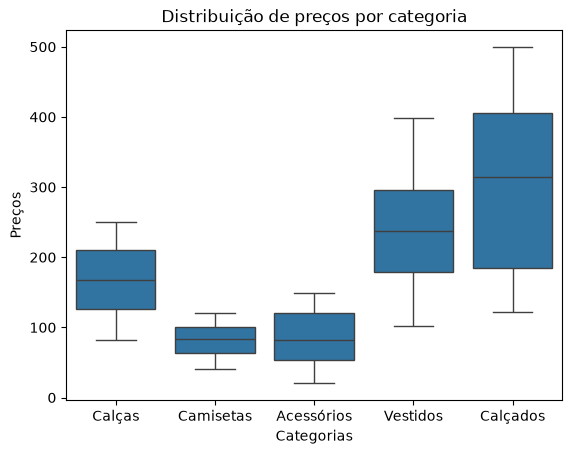

In [71]:
# Exercicio 10
# Crie um grafico que compare a distribuicao do preco entre as
# diferentes categorias de produto. Coloque um titulo no grafico.
grafico = sns.boxplot(data=df_tratado,x="categoria_produto",y="preco")
grafico.set_title("Distribuição de preços por categoria")
grafico.set_xlabel("Categorias")
grafico.set_ylabel("Preços")


NameError: name 'graficos' is not defined

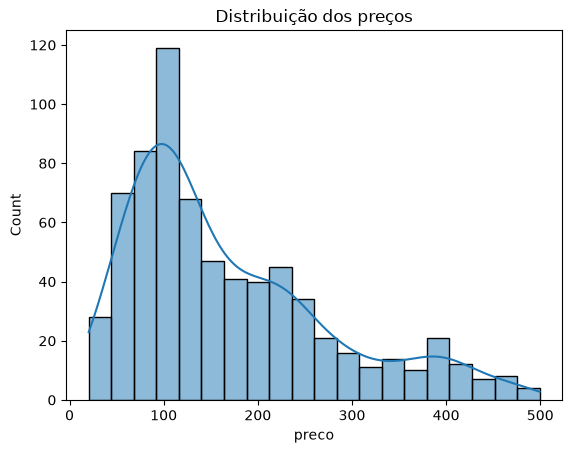

In [79]:
# Exercicio 11
# Crie um grafico que mostre a distribuicao dos precos dos produtos.
# Coloque um titulo no grafico.
grafico = sns.histplot(data=df_tratado,x=df_tratado["preco"],kde=True,bins=20);
grafico.set_title("Distribuição dos preços");
graficos.set_xlabel("Preços");
grafico.set_ylabel("Quantidade de produtos vendidos");